---   
 <img align="left" width="75" height="75"  src="https://upload.wikimedia.org/wikipedia/en/c/c8/University_of_the_Punjab_logo.png"> 

<h1 align="center">Department of Data Science</h1>
<h1 align="center">Course: Tools and Techniques for Data Science</h1>

---
<h3><div align="right">Instructor: Muhammad Arif Butt, Ph.D.</div></h3>    

<h1 align="center">Lecture 6.22 (Logistic Regression: Part-III)</h1>

<a href="https://colab.research.google.com/github/arifpucit/data-science/blob/master/Section-4-Mathematics-for-Data-Science/Lec-4.1(Descriptive-Statistics).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <img align="center" width="900" src="images/ml-topimg1.png"  >

# Learning agenda of this notebook

- EDA of Heart Disease Dataset
- Training a Logistic Regression Model
- Evaluation Metrics of Classification Models
    - Confusion Matrix
    - Accuracy
    - Accuracy Paradox
    - Precision
    - Recall
    - F-1 Score
    - F-$\beta$ Score
    - Precision Recall Tradeoff
    - ROC Curve and AUC Score
- Hyperparameters for Logistic Regression
    
- Task To Do (Assignment)

In [1]:
import numpy as np # np is short for numpy
import pandas as pd # pandas is so commonly used, it's shortened to pd
import matplotlib.pyplot as plt
import seaborn as sns # seaborn gets shortened to sns

%matplotlib inline 

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import plot_roc_curve

# 1. Load Dataset

### (i) Toy Datasets (`datasets.load_XXX()` methods)
https://scikit-learn.org/stable/datasets/toy_dataset.html#toy-datasets

- Scikit-learn comes with a few small standard datasets that do not require to download any file from some external website.
- These datasets are useful to quickly illustrate the behavior of the various algorithms implemented in scikit-learn. They are however often too small to be representative of real world machine learning tasks.
- Don’t be fooled by the word “toy”. These datasets are powerful and serve as a strong starting point for learning ML
- These toy datasets are broadly categorised into two types:

- <font face = "Garamond" color=blue size=4>Regression</font><br>
    - Boston house prices dataset
    - Diabetes dataset
    - Linnerud dataset (Multi-output Regression)
    - 
- <font face = "Garamond" color=blue size=4>Classification</font><br>
    - Iris plants dataset
    - Optical recognition of handwritten digits dataset
    - Wine recognition dataset
    - Breast cancer wisconsin (diagnostic) dataset¶
    
### (ii) Real World Datasets (`datasets.fetch_XXX()` methods)
https://scikit-learn.org/stable/datasets/real_world.html
- Scikit-learn provides tools to load larger datasets, downloading them if necessary.

- <font face = "Garamond" color=blue size=4>Regression</font><br>
    - California Housing dataset
- <font face = "Garamond" color=blue size=4>Classification</font><br>
    - The Olivetti faces dataset
    - The 20 newsgroups text dataset
    - The Labeled Faces in the Wild face recognition dataset
    - Forest covertypes
    - RCV1 dataset
    - Kddcup 99 dataset

### (iii) Downloading Datasets from Public ML Repositories (`fetch_XXX()` and `fetch_openml()` methods)
- Kaggle: https://www.kaggle.com/datasets

- UCI ML Repository: https://archive.ics.uci.edu/ml/index.php

- OpenML Repository: https://www.openml.org/

### (iv) Random Sample Generators
- In addition, scikit-learn includes various random sample generators that can be used to build artificial datasets of controlled size and complexity.
- These generators produce a matrix of features and corresponding discrete targets.
    - `make_regression()`
    - `make_classification()`
    - `make_moons()`
    - `make_circles()`
    - `make_blobs()`
- Please visit https://scikit-learn.org/stable/datasets/sample_generators.html for details.

### UCI ML Repository: https://archive.ics.uci.edu/ml/datasets/heart+Disease

In [2]:
from sklearn import datasets
bunch_object = datasets.fetch_openml(name='heart-disease', version=1)
bunch_object.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
# We want our plots to appear in the notebook
%matplotlib inline 

df = pd.DataFrame(bunch_object.data, columns=bunch_object.feature_names)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,3.0,145.0,233.0,1.0,0.0,150.0,0.0,2.3,0.0,0.0,1.0,1.0
1,37.0,1.0,2.0,130.0,250.0,0.0,1.0,187.0,0.0,3.5,0.0,0.0,2.0,1.0
2,41.0,0.0,1.0,130.0,204.0,0.0,0.0,172.0,0.0,1.4,2.0,0.0,2.0,1.0
3,56.0,1.0,1.0,120.0,236.0,0.0,1.0,178.0,0.0,0.8,2.0,0.0,2.0,1.0
4,57.0,0.0,0.0,120.0,354.0,0.0,1.0,163.0,1.0,0.6,2.0,0.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57.0,0.0,0.0,140.0,241.0,0.0,1.0,123.0,1.0,0.2,1.0,0.0,3.0,0.0
299,45.0,1.0,3.0,110.0,264.0,0.0,1.0,132.0,0.0,1.2,1.0,0.0,3.0,0.0
300,68.0,1.0,0.0,144.0,193.0,1.0,1.0,141.0,0.0,3.4,1.0,2.0,3.0,0.0
301,57.0,1.0,0.0,130.0,131.0,0.0,1.0,115.0,1.0,1.2,1.0,1.0,3.0,0.0


The following are the features we'll use to predict our target variable (heart disease or no heart disease).

1. age - age in years 
2. sex - (1 = male; 0 = female) 
3. cp - chest pain type 
    * 0: Typical angina: chest pain related decrease blood supply to the heart
    * 1: Atypical angina: chest pain not related to heart
    * 2: Non-anginal pain: typically esophageal spasms (non heart related)
    * 3: Asymptomatic: chest pain not showing signs of disease
4. trestbps - resting blood pressure (in mm Hg on admission to the hospital)
    * anything above 130-140 is typically cause for concern
5. chol - serum cholestoral in mg/dl 
    * serum = LDL + HDL + .2 * triglycerides
    * above 200 is cause for concern
6. fbs - (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false) 
    * '>126' mg/dL signals diabetes
7. restecg - resting electrocardiographic results
    * 0: Nothing to note
    * 1: ST-T Wave abnormality
        - can range from mild symptoms to severe problems
        - signals non-normal heart beat
    * 2: Possible or definite left ventricular hypertrophy
        - Enlarged heart's main pumping chamber
8. thalach - maximum heart rate achieved 
9. exang - exercise induced angina (1 = yes; 0 = no) 
10. oldpeak - ST depression induced by exercise relative to rest 
    * looks at stress of heart during excercise
    * unhealthy heart will stress more
11. slope - the slope of the peak exercise ST segment
    * 0: Upsloping: better heart rate with excercise (uncommon)
    * 1: Flatsloping: minimal change (typical healthy heart)
    * 2: Downslopins: signs of unhealthy heart
12. ca - number of major vessels (0-3) colored by flourosopy 
    * colored vessel means the doctor can see the blood passing through
    * the more blood movement the better (no clots)
13. thal - thalium stress result
    * 1,3: normal
    * 6: fixed defect: used to be defect but ok now
    * 7: reversable defect: no proper blood movement when excercising 
14. target - have disease or not (1=yes, 0=no) (= the predicted attribute)

**Note:** No personal identifiable information (PPI) can be found in the dataset.

# 2. Exploratory Data Analysis (EDA)

Since EDA has no real set methodolgy, the following is a short check list you might want to walk through:

1. What question(s) are you trying to solve (or prove wrong)?
2. What’s missing from the data and how do you deal with it?
3. Are there any outliers and how to treat them?
4. What kind of data do you have and how do you treat different types?
5. How can you add, change or remove features to get more out of your data?
6. How your data is distributed and the correlation between different variables?

In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
df['sex'].value_counts()

1.0    207
0.0     96
Name: sex, dtype: int64

In [6]:
df['cp'].value_counts()

0.0    143
2.0     87
1.0     50
3.0     23
Name: cp, dtype: int64

In [7]:
df['target'].value_counts()

1.0    165
0.0    138
Name: target, dtype: int64

<AxesSubplot:xlabel='target', ylabel='count'>

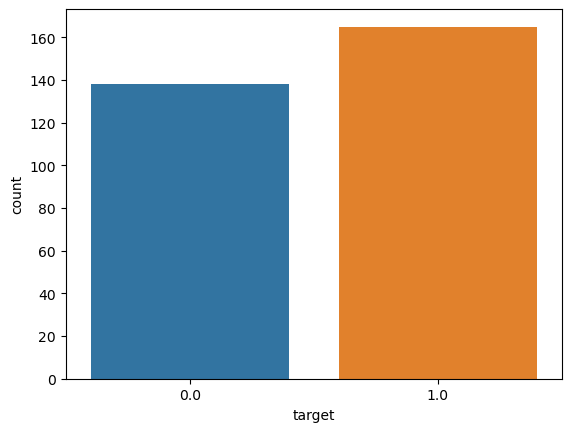

In [8]:
sns.countplot(data=df, x='target')

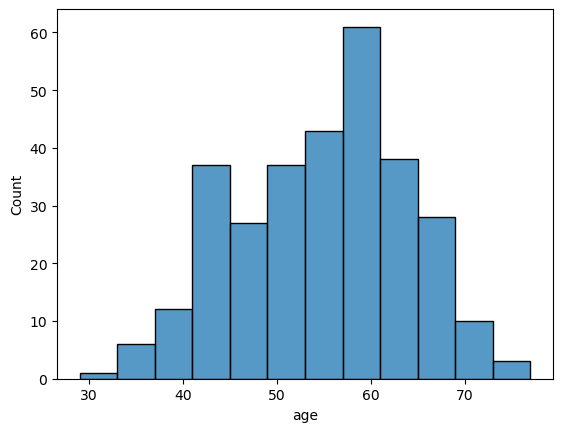

In [9]:
sns.histplot(data=df, x='age');

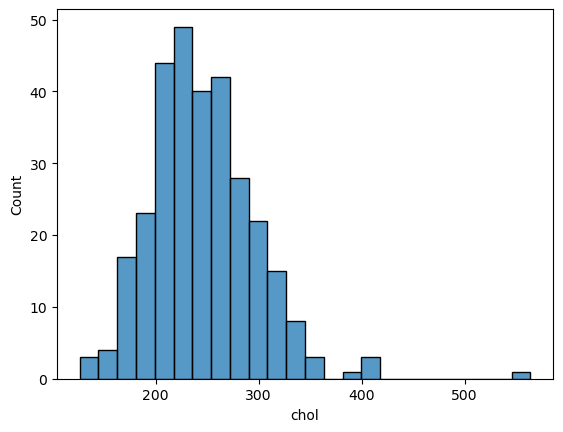

In [10]:
sns.histplot(data=df, x='chol');

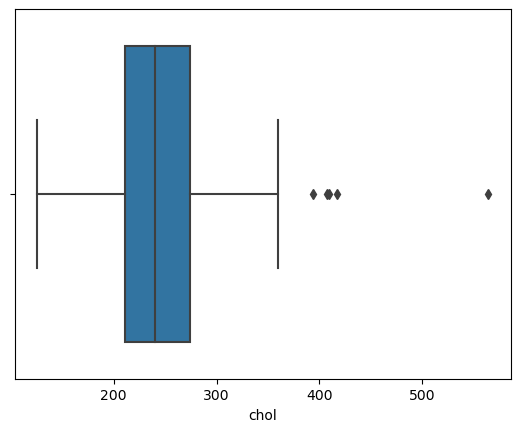

In [11]:
sns.boxplot(data=df, x='chol');

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  target    303 non-null    float64
dtypes: float64(14)
memory usage: 33.3 KB


In [13]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,3.0,145.0,233.0,1.0,0.0,150.0,0.0,2.3,0.0,0.0,1.0,1.0
1,37.0,1.0,2.0,130.0,250.0,0.0,1.0,187.0,0.0,3.5,0.0,0.0,2.0,1.0
2,41.0,0.0,1.0,130.0,204.0,0.0,0.0,172.0,0.0,1.4,2.0,0.0,2.0,1.0
3,56.0,1.0,1.0,120.0,236.0,0.0,1.0,178.0,0.0,0.8,2.0,0.0,2.0,1.0
4,57.0,0.0,0.0,120.0,354.0,0.0,1.0,163.0,1.0,0.6,2.0,0.0,2.0,1.0


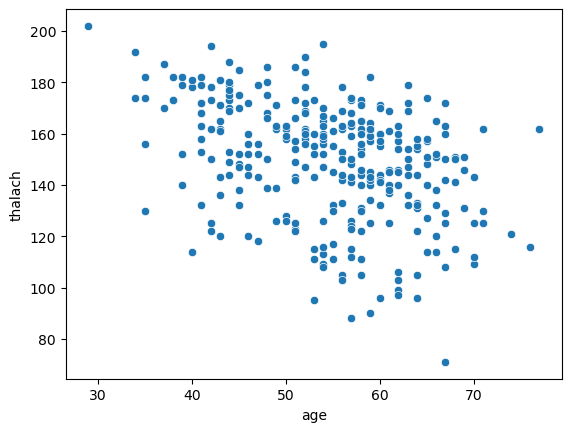

In [14]:
sns.scatterplot(data=df, x='age', y='thalach');

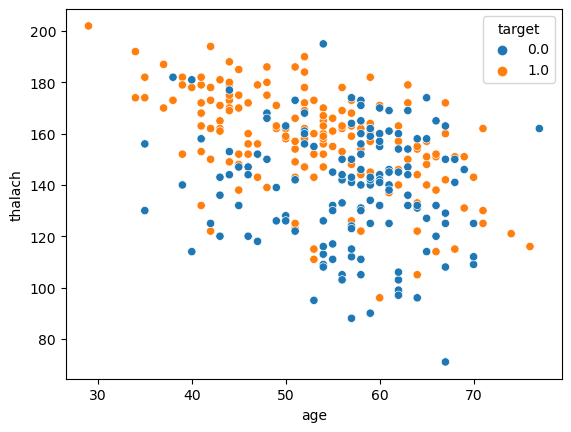

In [15]:
sns.scatterplot(data=df, x='age', y='thalach', hue='target');

In [16]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


<AxesSubplot:>

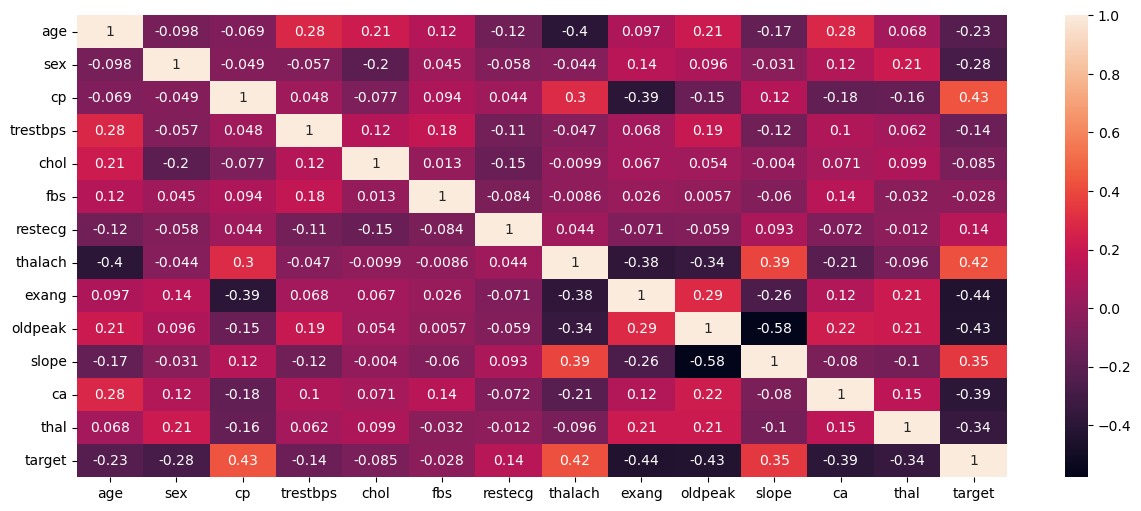

In [17]:
plt.figure(figsize=(15,6))
sns.heatmap(df.corr(), annot=True)

# 3. Model Training

**Do a Train-Test Split:**

In [18]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,3.0,145.0,233.0,1.0,0.0,150.0,0.0,2.3,0.0,0.0,1.0,1.0
1,37.0,1.0,2.0,130.0,250.0,0.0,1.0,187.0,0.0,3.5,0.0,0.0,2.0,1.0
2,41.0,0.0,1.0,130.0,204.0,0.0,0.0,172.0,0.0,1.4,2.0,0.0,2.0,1.0
3,56.0,1.0,1.0,120.0,236.0,0.0,1.0,178.0,0.0,0.8,2.0,0.0,2.0,1.0
4,57.0,0.0,0.0,120.0,354.0,0.0,1.0,163.0,1.0,0.6,2.0,0.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57.0,0.0,0.0,140.0,241.0,0.0,1.0,123.0,1.0,0.2,1.0,0.0,3.0,0.0
299,45.0,1.0,3.0,110.0,264.0,0.0,1.0,132.0,0.0,1.2,1.0,0.0,3.0,0.0
300,68.0,1.0,0.0,144.0,193.0,1.0,1.0,141.0,0.0,3.4,1.0,2.0,3.0,0.0
301,57.0,1.0,0.0,130.0,131.0,0.0,1.0,115.0,1.0,1.2,1.0,1.0,3.0,0.0


In [19]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=54)
len(X_train), len(y_train), len(X_test), len(y_test)

(242, 242, 61, 61)

**Scale the Data:**

In [20]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
scalar.fit(X_train)
scaled_X_train = scalar.transform(X_train)
scaled_X_test = scalar.transform(X_test)
len(scaled_X_train), len(scaled_X_test)

(242, 61)

In [21]:
scaled_X_train

array([[-1.33467373,  0.67015058, -0.95458269, ...,  1.04349839,
        -0.70898265, -0.48150478],
       [ 0.69176014, -1.49220195, -0.95458269, ..., -0.59628479,
        -0.70898265,  1.11471655],
       [ 0.80433979, -1.49220195, -0.95458269, ...,  1.04349839,
        -0.70898265, -0.48150478],
       ...,
       [ 0.69176014,  0.67015058,  0.93893379, ..., -0.59628479,
        -0.70898265, -0.48150478],
       [ 0.69176014,  0.67015058,  1.88569204, ..., -0.59628479,
         1.26313001, -0.48150478],
       [ 0.2414415 ,  0.67015058,  0.93893379, ...,  1.04349839,
         0.27707368,  1.11471655]])

In [22]:
scaled_X_train[1].mean()

-0.012808298234685767

In [23]:
scaled_X_train[1].std()

0.9146354242184234

**Instentiate and train the `LogisticRegression()` model**

In [24]:
from sklearn.linear_model import LogisticRegression

# Instentiate a model and fit it to training data with default hyperparameters
model = LogisticRegression()
model.fit(scaled_X_train, y_train)

LogisticRegression()

In [25]:
model.coef_

array([[-0.03949332, -0.75234087,  0.75877113, -0.32921334, -0.10390296,
         0.03871837,  0.30406442,  0.63910927, -0.29446201, -0.63868314,
         0.22677787, -0.73164988, -0.52449106]])

In [26]:
model.intercept_

array([0.17833406])

In [27]:
# Display probabilities of all 61 tes t points
probs = model.predict_proba(scaled_X_test)
probs

array([[0.00815874, 0.99184126],
       [0.11904725, 0.88095275],
       [0.02394178, 0.97605822],
       [0.74461485, 0.25538515],
       [0.68620514, 0.31379486],
       [0.9626643 , 0.0373357 ],
       [0.33800871, 0.66199129],
       [0.03318872, 0.96681128],
       [0.68017285, 0.31982715],
       [0.07128913, 0.92871087],
       [0.1785114 , 0.8214886 ],
       [0.9907996 , 0.0092004 ],
       [0.9103587 , 0.0896413 ],
       [0.25066682, 0.74933318],
       [0.04469425, 0.95530575],
       [0.48843381, 0.51156619],
       [0.11135776, 0.88864224],
       [0.30970563, 0.69029437],
       [0.66644289, 0.33355711],
       [0.99622629, 0.00377371],
       [0.00864235, 0.99135765],
       [0.9794142 , 0.0205858 ],
       [0.41305354, 0.58694646],
       [0.92827737, 0.07172263],
       [0.98612426, 0.01387574],
       [0.26777933, 0.73222067],
       [0.99233132, 0.00766868],
       [0.1145202 , 0.8854798 ],
       [0.35361946, 0.64638054],
       [0.99413058, 0.00586942],
       [0.

In [28]:
# Ignore Class 0 and consider class 1 only, i.e., the probability of belonging to class 1  (Heart Patient)
y_prob = probs[:,1]
y_prob

array([0.99184126, 0.88095275, 0.97605822, 0.25538515, 0.31379486,
       0.0373357 , 0.66199129, 0.96681128, 0.31982715, 0.92871087,
       0.8214886 , 0.0092004 , 0.0896413 , 0.74933318, 0.95530575,
       0.51156619, 0.88864224, 0.69029437, 0.33355711, 0.00377371,
       0.99135765, 0.0205858 , 0.58694646, 0.07172263, 0.01387574,
       0.73222067, 0.00766868, 0.8854798 , 0.64638054, 0.00586942,
       0.53079837, 0.94461409, 0.97144974, 0.99689867, 0.87154038,
       0.97651181, 0.54186077, 0.00691448, 0.92193046, 0.91501052,
       0.99127229, 0.9574321 , 0.05350028, 0.18595097, 0.78369623,
       0.07246424, 0.91333947, 0.69453775, 0.49362162, 0.29029273,
       0.31840982, 0.04016536, 0.71184106, 0.01078019, 0.77571284,
       0.95203588, 0.87210665, 0.62531545, 0.64639495, 0.93483498,
       0.99352217])

In [29]:
# Threshold value of Probability
# Let us map all probabilities >= 0.5 to a discrete value of 1 and else 0
output = np.array([1.0 if p>=0.5 else 0.0 for p in y_prob])
output

array([1., 1., 1., 0., 0., 0., 1., 1., 0., 1., 1., 0., 0., 1., 1., 1., 1.,
       1., 0., 0., 1., 0., 1., 0., 0., 1., 0., 1., 1., 0., 1., 1., 1., 1.,
       1., 1., 1., 0., 1., 1., 1., 1., 0., 0., 1., 0., 1., 1., 0., 0., 0.,
       0., 1., 0., 1., 1., 1., 1., 1., 1., 1.])

In [30]:
# Sklearn uses a default threshold value of 0.5 and outputs a discrete value
y_pred = model.predict(scaled_X_test)
y_pred

array([1., 1., 1., 0., 0., 0., 1., 1., 0., 1., 1., 0., 0., 1., 1., 1., 1.,
       1., 0., 0., 1., 0., 1., 0., 0., 1., 0., 1., 1., 0., 1., 1., 1., 1.,
       1., 1., 1., 0., 1., 1., 1., 1., 0., 0., 1., 0., 1., 1., 0., 0., 0.,
       0., 1., 0., 1., 1., 1., 1., 1., 1., 1.])

>- By `increasing` the threshold from 0.5 `False Negative` rate increases
>- By `decreasing` the threshold from 0.5 `False Positive` rate increases

> **In case of two input features (previous sessions), we also visually plotted the decision boundry which was a line. But for this dataset (having thirteen input features) the decision boundry will be a hyperplane, which is difficult to visualize.**

# 4. Evaluation Metrics for Classification Models
<h3 align="center"><div class="alert alert-success" color=magenta style="margin: 20px">Evaluation allows us to check how well our trained model is performing on data that has never been used for training </h3>

In [31]:
from sklearn.metrics import SCORERS
sorted(SCORERS)

['accuracy',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'average_precision',
 'balanced_accuracy',
 'completeness_score',
 'explained_variance',
 'f1',
 'f1_macro',
 'f1_micro',
 'f1_samples',
 'f1_weighted',
 'fowlkes_mallows_score',
 'homogeneity_score',
 'jaccard',
 'jaccard_macro',
 'jaccard_micro',
 'jaccard_samples',
 'jaccard_weighted',
 'max_error',
 'mutual_info_score',
 'neg_brier_score',
 'neg_log_loss',
 'neg_mean_absolute_error',
 'neg_mean_absolute_percentage_error',
 'neg_mean_gamma_deviance',
 'neg_mean_poisson_deviance',
 'neg_mean_squared_error',
 'neg_mean_squared_log_error',
 'neg_median_absolute_error',
 'neg_root_mean_squared_error',
 'normalized_mutual_info_score',
 'precision',
 'precision_macro',
 'precision_micro',
 'precision_samples',
 'precision_weighted',
 'r2',
 'rand_score',
 'recall',
 'recall_macro',
 'recall_micro',
 'recall_samples',
 'recall_weighted',
 'roc_auc',
 'roc_auc_ovo',
 'roc_auc_ovo_weighted',
 'roc_auc_ovr',
 'roc_auc_ovr_we

In [32]:
y_test.values

array([1., 1., 1., 0., 0., 0., 0., 1., 0., 1., 1., 0., 0., 1., 1., 1., 1.,
       1., 0., 0., 1., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 1., 1., 1.,
       1., 1., 0., 0., 0., 1., 1., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
       0., 1., 0., 1., 1., 1., 1., 0., 1., 1.])

In [33]:
y_pred = model.predict(scaled_X_test)
y_pred

array([1., 1., 1., 0., 0., 0., 1., 1., 0., 1., 1., 0., 0., 1., 1., 1., 1.,
       1., 0., 0., 1., 0., 1., 0., 0., 1., 0., 1., 1., 0., 1., 1., 1., 1.,
       1., 1., 1., 0., 1., 1., 1., 1., 0., 0., 1., 0., 1., 1., 0., 0., 0.,
       0., 1., 0., 1., 1., 1., 1., 1., 1., 1.])

> By comparing the Ground Labels $(y)$ and Predicted Labels $(\hat{y})$ one can calculate the `Accuracy` of the model:<br> $Accuracy = \large \frac{\text{Count of correct answers of Classifier}}{\text{Count of all Qs asked from Classifier}}$
 


|           | Positive Class| Negative Class |
|-----------| ----------- | ----------- |
|Heart Disease| Heart Patient| Healthy  |
|Email      | SPAM| HAM  |
|Tumor      | Malignant| Benign  |
|Transaction      | Fraud| Not Fraud  |
|Disease      | Yes| No  |
|Binary      | 1| 0  |

##  Hello TP, TN, FP, FN
<img align="center" width="800"  src="images/log20a.png"  > 

- **True Positive (TP):** Number of data points with `y=1` and are classified as $\hat y = 1$ 
- **True Negative (TN):** Number of data points with `y=0` and are classified as $\hat y = 0$ 
- **False Positive (FP):** Number of data points with `y=0` and are classified as $\hat y = 1$ 
- **False Negative (FN):** Number of data points with `y=1` and are classified as $\hat y = 0$ 

## a. Confusion Matrix
- [`confusion_matrix()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
- [`confusionmatrixdisplay()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)

<h4 align="center"><div class="alert alert-success" style="margin: 20px">A Confusion Matrix also called contingency matrix is a $n\times n$ matrix used to define the performance of classification algorithms (where n is the number of classes being predicted)</h4>

<img align="center" width="400"  src="images/log21a.png"  > 
<h4 align="center"><div class="alert alert-success" style="margin: 20px">The Confusion Matrix is not confusing for humans</h4>

In [34]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[21,  8],
       [ 1, 31]])

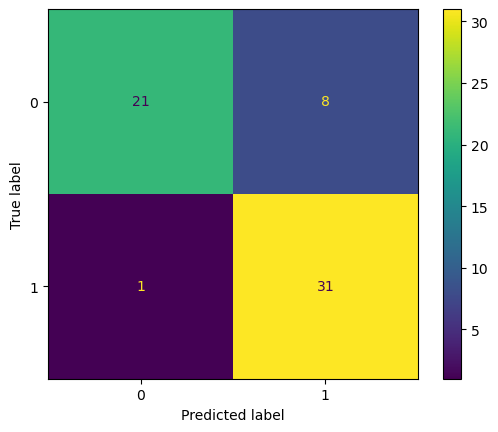

In [35]:
# Pass Confusion Matrix to ConfusionMatrixDisplay() method
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot();

> **`ConfusionMatrixDisplay()` method has gone obsolete in Sklearn's version 1.2 onwards. So you should prefer using either the `ConfusionMatrixDisplay.from_predictions()` method or the `ConfusionMatrixDisplay.from_estimator()` method**

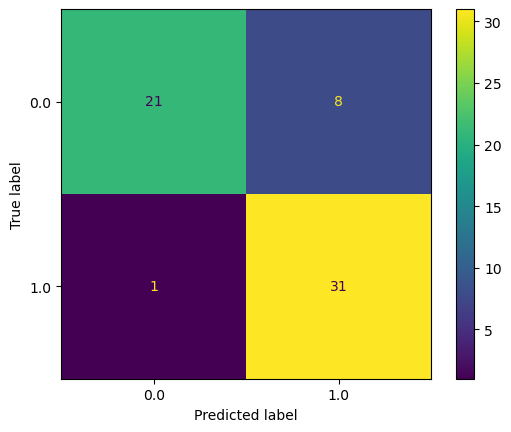

In [36]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred);

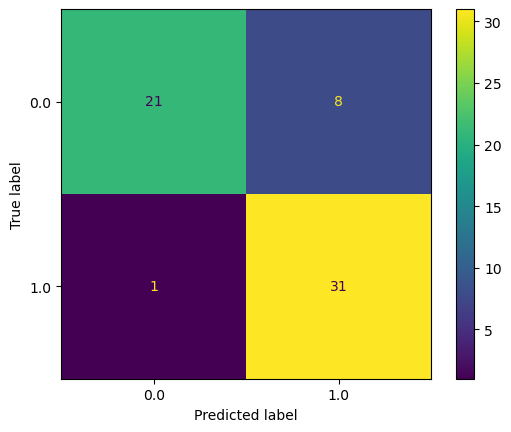

In [37]:
ConfusionMatrixDisplay.from_estimator(model, scaled_X_test, y_test);

<img align="right" width="400"  src="images/log22b.png"  > 

## b. Accuracy
[`accuracy_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html#sklearn.metrics.accuracy_score)

- **How frequently the model predicted correctly?**

\begin{equation}
Accuracy \hspace{0.5cm} = \hspace{0.5cm} \frac{\text{Count of correct answers of Classifier}}{\text{Count  of all Qs asked from Classifier}}\hspace{2cm}
\end{equation}

\begin{equation}
Accuracy \hspace{0.5cm} = \hspace{0.5cm} \frac{TP + TN}{TP + TN + FP + FN}\hspace{5cm}
\end{equation}

\begin{equation}
Accuracy \hspace{0.5cm} = \hspace{0.5cm} \frac{31 + 21}{31 + 21 + 8 + 1}\hspace{0.5cm} = \hspace{0.5cm} \frac{52}{61}\hspace{0.5cm} = \hspace{0.5cm} 0.852
\end{equation}
- **Accuracy score will be zero, if TP=TN=0 and Accuracy will be one, if FN=FP=0**

In [39]:
confusion_matrix(y_test,y_pred)

array([[21,  8],
       [ 1, 31]])

In [40]:
np.reshape(confusion_matrix(y_test,y_pred), (-1))

array([21,  8,  1, 31])

In [41]:
tn,fp,fn,tp = np.reshape(confusion_matrix(y_test,y_pred), (-1))
accuracy = (tp+tn)/(tp+tn+fp+fn)
print("Accuracy= ", accuracy)

Accuracy=  0.8524590163934426


In [38]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8524590163934426

<img align="right" width="450"  src="images/log23.png"  > 

### The Accuracy Paradox
- Accuracy does not prove to be a good evaluation metric in case of imbalance data sets
<br><br>
\begin{equation}
Accuracy \hspace{0.1cm} = \hspace{0.1cm} \frac{TP + TN}{TP + TN + FP + FN}\hspace{0.1cm} = \hspace{0.1cm} \frac{0 + 990}{0 + 990 + 0 + 10}\hspace{0.1cm} = \hspace{0.1cm} 0.95
\end{equation}

<br><br>

- `A classifier that always predicts the majority class, in a highly imbalanced dataset, will always have a high accuracy score.`
<br><br>
- **Conclusion:** We should not rely solely on Accuracy as a metric. This is where Precision, Recall and F1 Score comes in :)

## c. Precision
[`precision_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html)

- **Out of all the times model predicted Positive, how many times was it correct?**
- **Precision evaluates a model based on False Positive (Type-I Error)**
- **Which of the following two models is better?**

<img align="center" width="600"  src="images/log24a.png"  > 

\begin{equation}
\text{Precision} \hspace{0.1cm} = \hspace{0.1cm} \frac{\text{True Positives}}{\text{Predicted Positives}}\hspace{0.1cm} = \frac{TP}{TP + FP}
\end{equation}
<br><br>
\begin{equation}
\text{Precision for Model A} \hspace{0.1cm} = \hspace{0.1cm} \frac{100}{100 + 30} =  \frac{100}{130} = 0.769
\end{equation}
<br><br>
\begin{equation}
\text{Precision for Model B} \hspace{0.1cm}  = \frac{100}{100 + 10} =  \frac{100}{110} = 0.909
\end{equation}
    
>- **In case of Ham/Spam classifier, False Positives are more dangerous. Since Precision score of Model B is greater than Model A, therefore, we select Model B**

<font face = "Garamond" color=green size=4>  So in case if you want to miniminze False Positives (Type-I Error), you use Precesion as evaluation metric of your model.</font>

<img align="right" width="450"  src="images/log22c.png"  > 

### Precision Score for Heart Disease Dataset

<br><br>
\begin{equation}
\text{Precision} \hspace{0.1cm} = \frac{TP}{TP + FP} \hspace{0.1cm}  = \frac{31}{31 + 8} =  \frac{31}{39} = 0.7948
\end{equation}
<br><br>
- **Precision score will be zero, if TP=0 and Precision will be one, if FP=0**

In [42]:
from sklearn.metrics import precision_score
precision_score(y_test, y_pred)

0.7948717948717948

## d. Recall (a.k.a Sensitivity)
[`recall_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html)
- **Out of all the times actual class was Positive, how many times the model was correct?**
- **Recall evaluates a model based on False Negative (Type-II Error)**
- **Which of the following two models is better?**

<img align="center" width="700"  src="images/log25b.png"  > 

\begin{equation}
\text{Recall} \hspace{0.1cm} = \hspace{0.1cm} \frac{\text{True Positives}}{\text{Real Positives}}\hspace{0.1cm} = \frac{TP}{TP + FN}
\end{equation}
<br><br>
\begin{equation}
\text{Recall for Model A} \hspace{0.1cm} = \hspace{0.1cm} \frac{1000}{1000 + 200} =  \frac{1000}{1200} = 0.83
\end{equation}
<br><br>
\begin{equation}
\text{Recall for Model B} \hspace{0.1cm}  = \frac{1000}{1000 + 500} =  \frac{1000}{1500} = 0.666
\end{equation}
    
>- **In case of Healthy/Cancer classifier, False Nehatives are more dangerous.Since Recall score of Model A is greater than Model B, therefore, we select Model A**

<font face = "Garamond" color=green size=4>  So in case if you want to miniminze False Negatives (Type-II Error), you use Recall as evaluation metric of your model.</font>

<img align="right" width="450"  src="images/log22recall.png"  > 

### Recall Score for Heart Disease Dataset

<br><br>
\begin{equation}
\text{Recall} \hspace{0.1cm} = \frac{TP}{TP + FN} \hspace{0.1cm}  = \frac{31}{31 + 1} =  \frac{31}{32} = 0.968
\end{equation}

<br><br>
- **Recall score will be zero, if TP=0 and Recall will be one, if FN=0**

In [43]:
from sklearn.metrics import recall_score
recall_score(y_test, y_pred)

0.96875

## A Real 100 $ Question

<h3 align="center"><div class="alert alert-success" style="margin: 20px">To classify cats/dogs, should we go for a high precision model or a high recall model?</h3>

<img align="center" width="800"  src="images/log27.png"  > 

<br><br>
<font face = "Garamond" color=green size=4>  In this case, we cannot make out wheather to minimize False Positives or False Negatives, so we go for F-1 Score.</font>

## e. F-1 Score
- [`f1_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)
- [`classification_report()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)

- Precision and Recall alone do not solve the Accuracy Paradox. So, we combine both these metrics to create a new metric called F1 Score, which is harmonic mean of precision and recall. 
- We use harmonic mean instead of arithmetic mean because harmonic mean punishes extreme values more. OR in simple words, the harmonic means goes to zero if either of the recall or precision ends up being zero

<img align="right" width="400"  src="images/log22b.png"  > 

$$ F1 = \large \frac{2}{\frac{1}{P}+\frac{1}{R}}$$<br>
$$ F1 = \large \frac{2PR}{P+R}$$

<br><br>
\begin{equation}
F1 \hspace{0.5cm} = \hspace{0.5cm} \frac{2*0.79487*0.96875}{0.79487+0.96875} \hspace{0.5cm}= \hspace{0.5cm} \frac{1.54}{1.76362} \hspace{0.5cm}=\hspace{0.5cm} 0.873
\end{equation}
<br><br>

- F1 score will be high, if **both** precision and recall are high.
- F1 score will be low, if **any** of precision or recall are low.

In [46]:
(0.7948717948717948+0.96875)/2

0.8818108974358974

In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy:  0.8524590163934426
Precision:  0.7948717948717948
Recall:  0.96875
F1 Score: 0.8732394366197183


In [47]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.95      0.72      0.82        29
         1.0       0.79      0.97      0.87        32

    accuracy                           0.85        61
   macro avg       0.87      0.85      0.85        61
weighted avg       0.87      0.85      0.85        61



## f. F-β Score

<img align="right" width="400"  src="images/log22b.png"  > 

- The F-β score is the weighted harmonic mean of precision and recall.
- We can choose to favor precision or recall by using an interpolation weight $\alpha$:
$$F = \frac{1}{\alpha \frac{1}{P}+(1-\alpha)\frac{1}{R}} = \frac{(\beta^2+1)PR}{\beta^2P+R}$$

$ where \; \; \beta = \frac{1-\alpha}{\alpha}$


- If $\beta$=1, then F-$\beta$ is the same as F1 Score
- $\beta$ -> 0 considers only `precision`, $\beta$ -> +∞ considers only `recall`

- To give more weight to `Precision`, we pick $\beta$ value in the interval `0 < $\beta$ < 1`.
- To give more weight to `Recall`, we pick a $\beta$ Value in the interval `1 < $\beta$ < +∞`
    


In [48]:
from sklearn.metrics import fbeta_score
print("F-β Score (β=1): ", fbeta_score(y_test, y_pred,beta=1))
print("F-β Score (β=0.5): ", fbeta_score(y_test, y_pred,beta=0.5))
print("F-β Score (β=10): ", fbeta_score(y_test, y_pred,beta=10))

F-β Score (β=1):  0.8732394366197183
F-β Score (β=0.5):  0.8244680851063829
F-β Score (β=10):  0.9666563754245135


# Summary of what we have done so far

<img align="center" width="1000"  src="images/log26.png"  > 

## g. Precision-Recall Tradeoff

<h3 align="center"><div class="alert alert-success" style="margin: 20px">If you increase precision, it will reduce recall and vice versa. <br><br>So by changing the threshold value one can change the positive and negative predictions</h3>

In [49]:
probs = model.predict_proba(scaled_X_test)
probs

array([[0.00815874, 0.99184126],
       [0.11904725, 0.88095275],
       [0.02394178, 0.97605822],
       [0.74461485, 0.25538515],
       [0.68620514, 0.31379486],
       [0.9626643 , 0.0373357 ],
       [0.33800871, 0.66199129],
       [0.03318872, 0.96681128],
       [0.68017285, 0.31982715],
       [0.07128913, 0.92871087],
       [0.1785114 , 0.8214886 ],
       [0.9907996 , 0.0092004 ],
       [0.9103587 , 0.0896413 ],
       [0.25066682, 0.74933318],
       [0.04469425, 0.95530575],
       [0.48843381, 0.51156619],
       [0.11135776, 0.88864224],
       [0.30970563, 0.69029437],
       [0.66644289, 0.33355711],
       [0.99622629, 0.00377371],
       [0.00864235, 0.99135765],
       [0.9794142 , 0.0205858 ],
       [0.41305354, 0.58694646],
       [0.92827737, 0.07172263],
       [0.98612426, 0.01387574],
       [0.26777933, 0.73222067],
       [0.99233132, 0.00766868],
       [0.1145202 , 0.8854798 ],
       [0.35361946, 0.64638054],
       [0.99413058, 0.00586942],
       [0.

In [50]:
y_prob = probs[:,1]
y_prob

array([0.99184126, 0.88095275, 0.97605822, 0.25538515, 0.31379486,
       0.0373357 , 0.66199129, 0.96681128, 0.31982715, 0.92871087,
       0.8214886 , 0.0092004 , 0.0896413 , 0.74933318, 0.95530575,
       0.51156619, 0.88864224, 0.69029437, 0.33355711, 0.00377371,
       0.99135765, 0.0205858 , 0.58694646, 0.07172263, 0.01387574,
       0.73222067, 0.00766868, 0.8854798 , 0.64638054, 0.00586942,
       0.53079837, 0.94461409, 0.97144974, 0.99689867, 0.87154038,
       0.97651181, 0.54186077, 0.00691448, 0.92193046, 0.91501052,
       0.99127229, 0.9574321 , 0.05350028, 0.18595097, 0.78369623,
       0.07246424, 0.91333947, 0.69453775, 0.49362162, 0.29029273,
       0.31840982, 0.04016536, 0.71184106, 0.01078019, 0.77571284,
       0.95203588, 0.87210665, 0.62531545, 0.64639495, 0.93483498,
       0.99352217])

### CM for Default Threshold of 0.5:

In [51]:
y_pred1 = np.array([1.0 if p>=0.5 else 0.0 for p in y_prob])
y_pred1

array([1., 1., 1., 0., 0., 0., 1., 1., 0., 1., 1., 0., 0., 1., 1., 1., 1.,
       1., 0., 0., 1., 0., 1., 0., 0., 1., 0., 1., 1., 0., 1., 1., 1., 1.,
       1., 1., 1., 0., 1., 1., 1., 1., 0., 0., 1., 0., 1., 1., 0., 0., 0.,
       0., 1., 0., 1., 1., 1., 1., 1., 1., 1.])

Precision Score: 0.7948717948717948
Recall Score: 0.96875


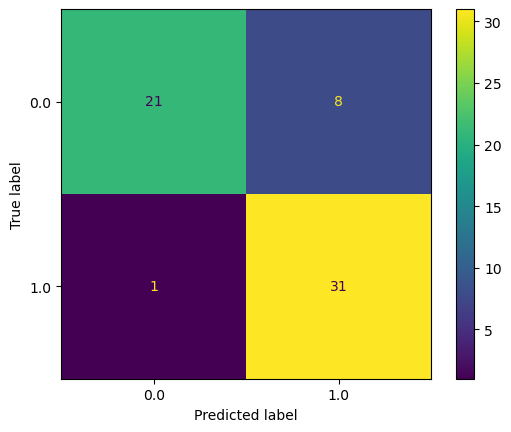

In [52]:
#disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred1))
#disp.plot();
ConfusionMatrixDisplay.from_predictions(y_test, y_pred1);
print("Precision Score:", precision_score(y_test, y_pred1))
print("Recall Score:", recall_score(y_test, y_pred1))

## CM for High Precision and Low Recall Model (Minimize Type-I Error (FP):**

In [53]:
y_pred2 = np.array([1 if p >= 0.9 else 0 for p in y_prob])
y_pred2

array([1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1])

Precision Score: 0.8888888888888888
Recall Score: 0.5


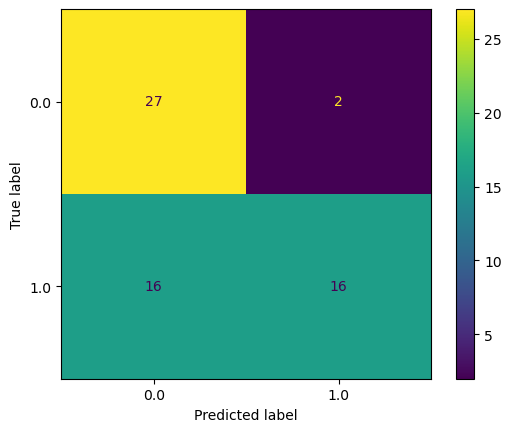

In [54]:
#disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred2))
#disp.plot();
ConfusionMatrixDisplay.from_predictions(y_test, y_pred2);
print("Precision Score:", precision_score(y_test, y_pred2))
print("Recall Score:", recall_score(y_test, y_pred2))

**Note:** 
>- `FP` are `reduced` from 8 to 2, while `FN` are `increased` from 1 to 16
>- `Precision` is `increased` from 0.79 to 0.88, while `Recall` is `reduced` from 0.96 to 0.5

## CM for High Recall and Low Precision Model (Minimize Type-II Error (FN):

In [55]:
y_pred3 = np.array([1 if p >= 0.2 else 0 for p in y_prob])
y_pred3

array([1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1])

Precision Score: 0.6956521739130435
Recall Score: 1.0


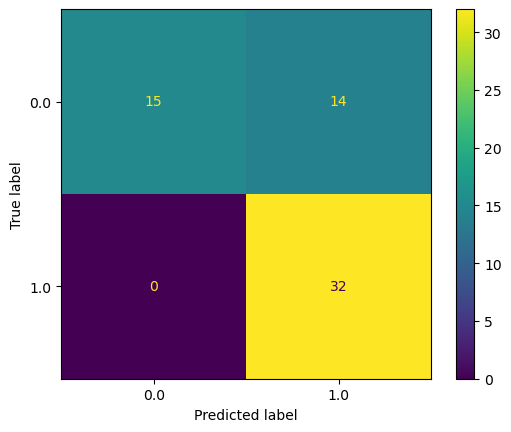

In [56]:
#disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred3))
#disp.plot();
ConfusionMatrixDisplay.from_predictions(y_test, y_pred3);
print("Precision Score:", precision_score(y_test, y_pred3))
print("Recall Score:", recall_score(y_test, y_pred3))

**Note:** 
>- `FP` are `increased` from 8 to 14, while `FN` are `decreased` from 1 to 0
>- `Recall` is `increased` from 0.96 to 1.0, while `Precision` is `reduced` from 0.79 to 0.69 


## h. ROC Curve and AUC Score


<h3 align="center"><div class="alert alert-success" style="margin: 20px">Receiver Operator Characteristic (ROC) Curve is a plot between the False Positive rate (FPR) along x-axis versus the True Positive rate (TPR) along y-axis at different probability threshold values between 0 and 1 <br><br>The Area under the ROC curve represents the goodness of the model or AUC Score </h3>
 
<img align="right" width="475"  src="images/roc-curve2.png"  > 

<br><br>

**False Positive Rate (1-Specificity):** The probability that a `negative sample` is `incorrectly` predicted in the positive class
$$\large FPR =  \frac{FP}{FP+TN}$$
<br><br><br>
**True Positive Rate (Sensitivity):** The probability that a `positive sample` is `correctly` predicted in the positive class
$$\large TPR =  \frac{TP}{TP+FN}$$

    
>- An AUC score of 1 means the classifier can perfectly distinguish between all the Positive and the Negative class points 
>- An AUC score of 0.5 means that the classifier is not working.
>- An AUC value of 0 shows that the classifier predicts all Negatives as Positives and vice versa.

### Example Data:

<img align="center" width="500"  src="images/roc-data.png"  > 
<img align="center" width="350"  src="images/roc-curve1.png"  > 

### ROC-AUC Score for Heart Disease Dataset

**Model Probabilities**

In [57]:
model_probs = model.predict_proba(scaled_X_test)[:,1] 
model_probs

array([0.99184126, 0.88095275, 0.97605822, 0.25538515, 0.31379486,
       0.0373357 , 0.66199129, 0.96681128, 0.31982715, 0.92871087,
       0.8214886 , 0.0092004 , 0.0896413 , 0.74933318, 0.95530575,
       0.51156619, 0.88864224, 0.69029437, 0.33355711, 0.00377371,
       0.99135765, 0.0205858 , 0.58694646, 0.07172263, 0.01387574,
       0.73222067, 0.00766868, 0.8854798 , 0.64638054, 0.00586942,
       0.53079837, 0.94461409, 0.97144974, 0.99689867, 0.87154038,
       0.97651181, 0.54186077, 0.00691448, 0.92193046, 0.91501052,
       0.99127229, 0.9574321 , 0.05350028, 0.18595097, 0.78369623,
       0.07246424, 0.91333947, 0.69453775, 0.49362162, 0.29029273,
       0.31840982, 0.04016536, 0.71184106, 0.01078019, 0.77571284,
       0.95203588, 0.87210665, 0.62531545, 0.64639495, 0.93483498,
       0.99352217])

In [58]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_true=y_test,  y_score=model_probs)

print("FPR: ", fpr)
print("\nTPR: ", tpr)
print("\nThresholds: ", thresholds)

FPR:  [0.         0.         0.         0.03448276 0.03448276 0.06896552
 0.06896552 0.10344828 0.10344828 0.20689655 0.20689655 0.27586207
 0.27586207 1.        ]

TPR:  [0.      0.03125 0.46875 0.46875 0.5     0.5     0.84375 0.84375 0.875
 0.875   0.9375  0.9375  1.      1.     ]

Thresholds:  [1.99689867 0.99689867 0.92871087 0.92193046 0.91501052 0.91333947
 0.71184106 0.69453775 0.69029437 0.64638054 0.58694646 0.53079837
 0.49362162 0.00377371]


In [59]:
# zip() is used to combine two or more iterables into a single iterable
pd.DataFrame(zip(thresholds, fpr, tpr), columns=["Threshold", "FPR", "TPR"])

,Threshold,FPR,TPR
0,1.996899,0.000000,0.00000
1,0.996899,0.000000,0.03125
2,0.928711,0.000000,0.46875
3,0.921930,0.034483,0.46875
4,0.915011,0.034483,0.50000
5,0.913339,0.068966,0.50000
6,0.711841,0.068966,0.84375
7,0.694538,0.103448,0.84375
8,0.690294,0.103448,0.87500
9,0.646381,0.206897,0.87500


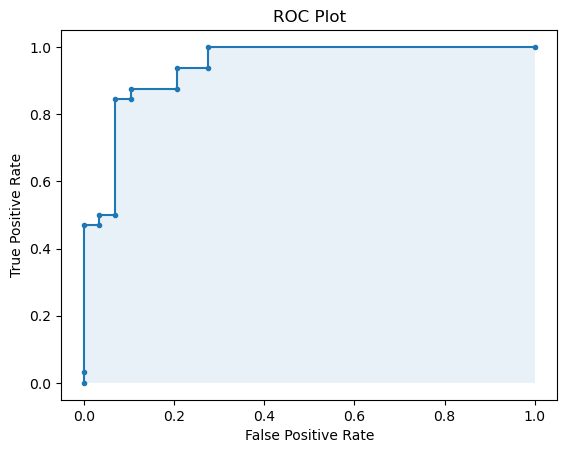

In [60]:
plt.plot(fpr, tpr, marker='.')
plt.fill_between(fpr, tpr, 0, alpha=0.1)
plt.title('ROC Plot')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

> The more that the curve hugs the top left corner of the plot, the better the model does at classifying the data into categories.

In [61]:
# To quantify, we can calculate the AUC, which tells us how much of the plot is located under the curve.
# The closer AUC is to 1, the better the model. 
#A model with an AUC equal to 0.5 is no better than a model that makes random classifications.
from sklearn.metrics import roc_auc_score
model_auc=  roc_auc_score(y_test, model_probs)
print("Model AUC Score: ", model_auc)

Model AUC Score:  0.9418103448275862


### How to speculate about the performance of the model?
- An excellent model has AUC near to the `1` which means it has a good measure of separability. A poor model has an AUC near `0` which means it has the worst measure of separability. In fact, it means it is reciprocating the result. It is predicting 0s as 1s and 1s as 0s. And when AUC is `0.5`, it means the model has no class separation capacity whatsoever. 
- As we know, ROC is a curve of probability. So let's plot the distributions of those probabilities. **Note:** `Red` distribution curve is of the positive class (patients with disease) and the `green` distribution curve is of the negative class(patients with no disease).

**Case 1:**
- This is an ideal situation. When two curves don’t overlap at all, means model has an ideal measure of separability. It is perfectly able to distinguish between positive class and negative class.

<img src="images/p15.webp">

**Case 2:**
- When two distributions overlap, we introduce type 1 and type 2 errors. Depending upon the threshold, we can minimize or maximize them. When AUC is 0.7, it means there is a 70% chance that the model will be able to distinguish between positive class and negative class.

<img src="images/p16.webp">


**Case 3:**
- This is the worst situation. When AUC is approximately 0.5, the model has no discrimination capacity to distinguish between positive class and negative class.

<img src="images/p17.webp">

**Case 4:**
- When AUC is approximately 0, the model is actually reciprocating the classes. It means the model is predicting a negative class as a positive class and vice versa.

<img src="images/p18.webp">
     
**How to use the AUC ROC curve for the multi-class model?**

- In a multi-class model, we can plot the `N number` of `AUC ROC Curves` for N number classes using the One vs ALL methodology. So for example, If you have three classes named X, Y, and Z, you will have one ROC for X classified against Y and Z, another ROC for Y classified against X and Z, and the third one of Z classified against Y and X.

# 5. Hyperparameters for Logistic Regression

- [`LogisticRegression()`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

In [63]:
model = LogisticRegression()
model.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'auto',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

**Hyperparameter Tuning Techniques:**
- `By Hand:` Select the hyperparameters values based on intuition/experience/guessing, train the model with the hyperparameters, and score on the validation data. Repeat process until you run out of patience or are satisfied with the results. 
- `GridSearchCV:` Set up a grid of hyperparameter values and for each combination, train a model and score on the validation data. In this approach, every single combination of hyperparameters values is tried which can be very inefficient!
- `RandomizedSearchCV:` Set up a grid of hyperparameter values and select random combinations to train the model and score. The number of search iterations is set based on time/resources.


#### Solver Parameters

The solver parameter in logistic regression is used to specify the algorithm that will be used to find the optimal set of coefficients for the model. The five options for the solver parameter are `newton-cg`, `lbfgs`, `liblinear`, `sag`, and `saga`. The choice of solver will depend on the size and characteristics of your dataset, and the desired trade-off between speed and accuracy. `newton-cg`, `lbfgs` and `sag` are more suited for larger datasets, while `liblinear` is more efficient for smaller datasets. `saga` is a solver that combines the benefits of `sag` and `lbfgs` and is generally recommended.

**newton-cg:** The Newton-Conjugate Gradient (Newton-CG) solver is an optimization algorithm used for finding the minimum of a function. It is a combination of Newton's method and the Conjugate Gradient method, and it is particularly well-suited for solving large-scale optimization problems in logistic regression.


**lbfgs:** The Limited-memory Broyden-Fletcher-Goldfarb-Shanno (LBFGS) solver is an optimization algorithm used for finding the minimum of a function. LBFGS is particularly well-suited for problems with a large number of parameters, such as logistic regression, as it can handle a large number of features and still converge quickly. 

**liblinear:** The liblinear solver is an optimization algorithm used for solving linear classification problems, such as logistic regression. It is based on a linear support vector machine (SVM) and is implemented in the C++ library LIBLINEAR.

**saga:** The SAGA (Stochastic Average Gradient Descent) solver is an optimization algorithm used for solving large-scale optimization problems, such as logistic regression. It is an extension of the standard stochastic gradient descent (SGD) algorithm and can handle both L1 and L2 regularization.

**sag:** The Stochastic Average Gradient (SAG) solver is an optimization algorithm used for solving large-scale optimization problems, such as logistic regression. It is a variant of the SAGA algorithm and also uses a mini-batch approach to update the parameters of the model by computing the gradient of the loss function with respect to the parameters using a small random subset of the training data.

**Supported Penalties by Different Solvers are:**
- `lbfgs`     $\hspace{2.5cm}$ -->$\hspace{.5cm}$ ['l2', None]

- `liblinear` $\hspace{1.5cm}$  -->$\hspace{.5cm}$ ['l1', 'l2']

- `newton-cg` $\hspace{1.5cm}$ -->$\hspace{.5cm}$ ['l2', None]

- `newton-cholesky` $\hspace{0.2cm}$ --> $\hspace{.5cm}$['l2', None]

- `sag`    $\hspace{2.8cm}$          --> $\hspace{.5cm}$['l2', None]

- `saga`  $\hspace{2.5cm}$           --> $\hspace{.5cm}$['elasticnet', 'l1', 'l2', None]

# Task to Do: Logistic Regression (Titanic Dataset)

In [62]:
from sklearn.datasets import fetch_openml
titanic = datasets.fetch_openml(name='titanic', version=1, as_frame=True)
df = pd.DataFrame(titanic.data, columns=titanic.feature_names)
df['target'] = titanic.target
df

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,target
0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1
1,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",1
2,1.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,None,NaN,"Montreal, PQ / Chesterville, ON",0
3,1.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,None,135.0,"Montreal, PQ / Chesterville, ON",0
4,1.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,None,NaN,"Montreal, PQ / Chesterville, ON",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3.0,"Zabour, Miss. Hileni",female,14.5000,1.0,0.0,2665,14.4542,None,C,None,328.0,None,0
1305,3.0,"Zabour, Miss. Thamine",female,NaN,1.0,0.0,2665,14.4542,None,C,None,NaN,None,0
1306,3.0,"Zakarian, Mr. Mapriededer",male,26.5000,0.0,0.0,2656,7.2250,None,C,None,304.0,None,0
1307,3.0,"Zakarian, Mr. Ortin",male,27.0000,0.0,0.0,2670,7.2250,None,C,None,NaN,None,0


#### VARIABLE DESCRIPTIONS
`Pclass` -> Passenger Class (1 = 1st; 2 = 2nd; 3 = 3rd).   
`survival` ->  Survival (0 = No; 1 = Yes)   
`name` -> Name    
`sex` -> Sex     
`age` -> Age     
`sibsp` -> Number of Siblings/Spouses Aboard        
`parch` -> Number of Parents/Children Aboard       
`ticket` -> Ticket Number            
`fare` -> Passenger Fare (British pound)          
`cabin` -> Cabin       
`embarked` -> Port of Embarkation (C = Cherbourg; Q = Queenstown; S = Southampton)       
`boat` -> Lifeboat        
`body` -> Body Identification Number       
`home.dest`->  Home/Destination 

**1. Data Preprocessing and EDA**

    - Detect and handle outliers
    - Detect and  impute missing values
    - Encode categorical features
    - Feature scaling
    - Feature Engineering (Drop unnecessary features)
    
**2. Train Test Split, Cross Validation**

**3. Training of Logistic Regression *Non-pipelined and Pipelined Model)**

**4. Model Evaluation**

**5. Feature Engineering (Optional)**

**6. Hyperparameter Tuning using GridSearchCV to get the best evaluation results**

**7. Saving the Model**

**8. Model Deployment using Streamlit or Flask**

# Sample Code for Breast Cancer Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score


bc = load_breast_cancer()
df = pd.DataFrame(bc.data, columns=bc.feature_names)
df['target'] = bc.target

X = df.drop(['target'], axis=1).values
y = df['target'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

model_lr = LogisticRegression(solver='saga', max_iter=10000)
model_lr.fit(X_train, y_train)

proba_lr = model_lr.predict_proba(X_test)[:, 1]
print("AUC Score", roc_auc_score(y_test, proba_lr))

fpr, tpr, thresholds = roc_curve(y_test, proba_lr)
plt.plot(fpr, tpr, label='logistic')
plt.fill_between(fpr, tpr, 0, alpha=0.1)

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

In [ ]:
# number of rows and columns 
df.shape

In [ ]:
# dtypes of all the columns
df.dtypes

In [ ]:
# check missing values
df.isna().sum()

**Observation:** We can see that `age`, `cabin`, `boat`, `body` and `home.dest` have some missing values

In [ ]:
# descriptive view of the data
df.describe()

**Observation:** We can see that `fare` has high value for `std`. So, we need to normalize it.

In [ ]:
# info of the data
df.info()

In [ ]:
# separate numeric columns and categorical columns of the data
num_colunms = df.select_dtypes(include=np.number).columns.to_list()
cat_columns = df.select_dtypes('O').columns.to_list()
num_colunms

In [ ]:
# df.select_dtypes(include=np.number)

In [ ]:
# the correlation  matrix of numeric columns
df.corr()

### Exploratory Data Analysis
#### Univariate Analysis

In [ ]:
num_colunms

In [ ]:
# for i in num_colunms:
#     for j in num_colunms:
#         print(i,j)

In [ ]:
sns.set_style("darkgrid")
sns.set(rc={'figure.figsize':(9,7)})
sns.countplot('pclass', data=df);
plt.title("Pclass Distribution", fontsize= 30);

**Observation:** More people are in class `3.0`, on the other hand, same number is in class `1.0`. and `2.0`.
Here, we need to find the reason why people in class `3.0` are more than other two classes.

In [ ]:
sns.countplot('sex', data=df);
plt.title("Sex Distribution", fontsize= 30);

**Observation:** Number of males are more than females in the dataset.

In [ ]:
sns.histplot(x = df.age, bins=30);
plt.title("Distribution of Age", fontsize=30);

**Observation:** Age of mostly people is beween 20 - 50. But there are also children in the data.

In [ ]:
sns.countplot('sibsp', data=df);
plt.title("sibsp distribution", fontsize= 30);

**Observation:** We can see that mostly people do not have their sibsp and more than 300 people have their sibsp.

In [ ]:
sns.countplot('parch', data=df);
plt.title("parent children distribution", fontsize= 30);

**Observation:** We can see that mostly parents do not have children. But some parents have one or two childs.

In [ ]:
sns.histplot(x = df['fare'], bins=40);
plt.title("Distribution of Fare", fontsize= 30);

**Observation:** We can see that range of fare is between 0-100 but there is some outliers in the data.

In [ ]:
sns.boxplot('fare', data=df);
plt.title("Boxplot of Fare", fontsize= 30);

**Observation:** We can also see that from above plot that there are outliers in the fare columns.

In [ ]:
sns.countplot('embarked', data=df);
plt.title("Distribution of Embarked", fontsize= 30);

**Observation:** We can see that mostly people belong to `S = Southampton`  embarked.

In [ ]:
sns.countplot('target', data=df);
plt.title("Distribution of Target", fontsize= 30);

**Observation:** Mostly people were not survived , on the other hand almost 500 people were survived.

#### Bivariate Analysis

In [ ]:
df.groupby(["target",'pclass'])['pclass'].count()

In [ ]:
sns.countplot(x = 'target', hue='pclass', data=df);
plt.title("Distribution of Target and pclass", fontsize= 30);

In [ ]:
sns.countplot(x = 'target', hue='sex', data=df);
plt.title("Distribution of Target vs Sex", fontsize= 30);

In [ ]:
sns.countplot(x = 'target', hue='sibsp', data=df);
plt.title("Distribution of Target vs Sibsp", fontsize= 30);

In [ ]:
sns.countplot(x = 'target', hue='embarked', data=df);
plt.title("Distribution of Target vs Embarked", fontsize= 30);

In [ ]:
sns.scatterplot(x='age', y='fare', data=df)
plt.title("Relationship of Age vs Fare", fontsize= 30);

#### Multi-variate Analysis

In [ ]:
sns.pairplot(df);

In [ ]:
# Let's make it look a little prettier
corr_matrix = df.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, 
            annot=True, 
            linewidths=0.5, 
            fmt= ".2f", 
            cmap="YlGnBu");

In [ ]:
plt.figure(figsize=(12,12))
sns.heatmap(df.corr(), annot=True);

## Data Preprocessing

### Percent of Missing in data

In [ ]:
(df.isna().sum()/len(df))*100

In [ ]:
# df.loc[:,df.isna().sum()>0]

In [ ]:
# percent of missing in data
(df.loc[:,df.isna().sum()>0].isna().sum()/len(df))*100

### Fill Missing values

- If `Age` and `Fare` is missing for a given row, I'll impute with their (median age, fare).
- If `Embarked` is missing for a riven row, I'll impute with "S" (the most common boarding port).
- I'll ignore `Cabin`,`boat`,`body`,`home.dext` as  variables. There are too many missing values for imputation.

In [ ]:
df['age'].fillna(df['age'].median(skipna=True), inplace=True)
df['fare'].fillna(df['age'].median(skipna=True), inplace=True)
df['embarked'].fillna(df['embarked'].value_counts().idxmax(), inplace=True)
df.drop(columns=['cabin','boat','body','home.dest'], axis=1, inplace=True)

In [ ]:
# percent of missing
df.isna().sum()

In [ ]:
df.head()

### Drop unnecessary Columns like `name`, `ticket`
These columns are not related to our model prediction.

In [ ]:
df.drop(columns=['name','ticket'], axis=1, inplace=True)

### Add new Column/Feature 
Both `sibsp` and `parch` relate to traveling with family. I'll combine these two variables/columns into one categorical variable, which represents if a person is traveling alone or not.

In [ ]:
(df['sibsp']+df['parch'])>0

In [ ]:
df['TravelAlone'] = np.where((df['sibsp']+df['parch'])>0,0,1)

In [ ]:
df.drop(['sibsp','parch'], axis=1, inplace=True)

In [ ]:
df.head(10)

In [ ]:
df.dtypes

### **Save Clean Data on the Local Disk**

In [ ]:
df.to_csv("datasets/cleaned_data.csv", index=False)

In [ ]:
# !ls

### **Load the cleaned Data**

In [ ]:
cleaned_data = pd.read_csv('datasets/cleaned_data.csv')
cleaned_data.head()

### Feature Encoding

In [ ]:
# extract numerical and categorical columns from the df
# numeric_cols = cleaned_data.select_dtypes(include=np.number).columns.to_list()
numeric_cols = ['pclass', 'age', 'fare', 'TravelAlone']
categorical_cols = ['sex','embarked']

In [ ]:
cleaned_data.columns

<img src="images/p20.webp">

#### Pipeline for Encoding of Numerical columns

In [ ]:
# Create a ColumnTransformer to handle numeric columns
numeric_transformer = ('scaler', StandardScaler())

# StandardScaler vs MinMaxScaler

#### Pipeline for Encoding of Categorical Columns

In [ ]:
# Create a ColumnTransformer to handle categorical columns
categorical_transformer = ('onehot', OneHotEncoder())

#### Pipeline for Column Transformer
We will Combine both numerical and categorical column using the Column Transformer module

In [ ]:
# Combine the transformers into a single ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

### Train Test Validate Split

In [ ]:
# select input features and target feature
X = cleaned_data.drop(['target'], axis=1)
X

In [ ]:
y = cleaned_data['target']
y

In [ ]:
cleaned_data.shape

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


In [ ]:
# Split the training set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
print(y_val.shape)
print(X_val.shape)

### Model Buidling
<img src="images/p132.png" height=500px width=500px>

In [ ]:
from sklearn.pipeline import Pipeline
model =  Pipeline([('preprocessor',preprocessor),
                   ('lr', LogisticRegression(max_iter=500))])
model

In [ ]:
# model.get_params()

In [ ]:
# fit the model on training dataset using fit method
model.fit(X_train, y_train)

In [ ]:
# X_train, y_train, y_test, y_pred, X_test
# X_test
# y_test-> true values
# y_pred -> predicted values

In [ ]:
# predict the result of the model using X_test dataset using predict method
y_pred = model.predict(X_test)
y_pred

### Model Evaluation using Train/Test Split

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score,precision_recall_curve 
from sklearn.metrics import roc_curve, auc, log_loss, accuracy_score, recall_score
from sklearn.metrics import accuracy_score


**Accuracy Score**

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Classification Accuracy: {accuracy:.3f}')

**Confusion Matric**

In [ ]:
Result = confusion_matrix(y_test, y_pred)
print(f'Confusion Matrix: \n{Result}')

sns.heatmap(Result, annot=True, fmt='.3g');

**Precision and Recall**

In [ ]:
precision = precision_score(y_test, y_pred, pos_label=1)

recall = recall_score(y_test, y_pred, pos_label="1")

print(f'Precision: {precision:.3f}, Recall: {recall:.3f}')


**F1 Score**

In [ ]:
# Import necessary libraries
f1 = f1_score(y_test, y_pred, pos_label="1")
print(f'F1 Score: {f1:.3f}')


In [ ]:
# Import necessary libraries
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve and AUC
y_pred_proba = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label="1")
auc = roc_auc_score(Y_test, y_pred_proba)
print(f'AUC: {auc:.3f}')


In [ ]:
print("Train/Test split result of Logistic Regression : ")
print(f'Classification Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}, Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}')
print(f'AUC: {auc:.3f}')

### Model evaluation based on K-fold cross-validation using `cross_val_score()` function with` validation data`

In [ ]:
model1 =  Pipeline([('preprocessor',preprocessor),
                   ('lr', LogisticRegression(max_iter=500))])


result_accuracy = cross_val_score(model1, X_val, y_val, cv=10, scoring="accuracy")

result_log_loss = cross_val_score(model1, X_val, y_val, cv=10, scoring="neg_log_loss")

result_auc = cross_val_score(model1, X_val, y_val, cv=10, scoring="roc_auc")

In [ ]:
# Results of the model using cross-validation 
print('K-fold cross-validation results:')
print(f"Average Accuracy : {result_accuracy.mean():.3f}")
print(f"Average Log Loss : {-result_log_loss.mean():.3f}")
print(f"Average AUC : {result_auc.mean():.3f}")

In [ ]:
model1.get_params()

### Hyper-Parameter Tunning of Logistic Regression Model using GridSearchCV 



> In this example, the `GridSearchCV` class is used to perform a grid search over the values of the hyper-parameters defined in the param_grid dictionary. The fit method is used to train the logistic regression model on the training data, and the best_params_ attribute is used to print the best hyper-parameters found by the grid search. The model's performance is then evaluated on the test set using the score method.

> You can use the `RandomizedSearchCV` class in a similar way to perform a random search for the best hyper-parameters of a logistic regression model. The main difference is that instead of specifying a grid of values for each hyper-parameter, you can specify a distribution from which the hyper-parameter values will be sampled randomly. This can be useful if you want to explore a larger range of hyper-parameter values, but don't want to specify every possible value.

Here is a list of some common hyperparameters that you can include in the param_grid for logistic regression:

- **C:** The inverse of the regularization strength. Higher values of C correspond to less regularization and larger model complexity.
- **penalty:** The type of regularization to be used. Options include 'l1' for L1 regularization and 'l2' for L2 regularization.
- **solver:** The algorithm to be used to optimize the logistic regression model. Options include 'newton-cg', 'lbfgs', 'liblinear', 'sag', and 'saga'.
- **max_iter:** The maximum number of iterations to be used by the solver. Higher values may result in better model convergence, but may also increase computation time.
- **tol:** The tolerance for the solver to consider the optimization as converged. Lower values may result in better model convergence, but may also increase computation time.
- **class_weight:** The weights to be used for the different classes in the dataset. Options include None for equal weights, 'balanced' for weights proportional to the inverse of the class frequencies, or a user-defined dictionary of weights.

Reference: 
- https://towardsdatascience.com/tuning-the-hyperparameters-of-your-machine-learning-model-using-gridsearchcv-7fc2bb76ff27
- https://vitalflux.com/grid-search-explained-python-sklearn-examples/

#### Solver Parameters

The solver parameter in logistic regression is used to specify the algorithm that will be used to find the optimal set of coefficients for the model. The five options for the solver parameter are `newton-cg`, `lbfgs`, `liblinear`, `sag`, and `saga`. The choice of solver will depend on the size and characteristics of your dataset, and the desired trade-off between speed and accuracy. `newton-cg`, `lbfgs` and `sag` are more suited for larger datasets, while `liblinear` is more efficient for smaller datasets. `saga` is a solver that combines the benefits of `sag` and `lbfgs` and is generally recommended.

**newton-cg:** The Newton-Conjugate Gradient (Newton-CG) solver is an optimization algorithm used for finding the minimum of a function. It is a combination of Newton's method and the Conjugate Gradient method, and it is particularly well-suited for solving large-scale optimization problems in logistic regression.


**lbfgs:** The Limited-memory Broyden-Fletcher-Goldfarb-Shanno (LBFGS) solver is an optimization algorithm used for finding the minimum of a function. LBFGS is particularly well-suited for problems with a large number of parameters, such as logistic regression, as it can handle a large number of features and still converge quickly. 

**liblinear:** The liblinear solver is an optimization algorithm used for solving linear classification problems, such as logistic regression. It is based on a linear support vector machine (SVM) and is implemented in the C++ library LIBLINEAR.

**saga:** The SAGA (Stochastic Average Gradient Descent) solver is an optimization algorithm used for solving large-scale optimization problems, such as logistic regression. It is an extension of the standard stochastic gradient descent (SGD) algorithm and can handle both L1 and L2 regularization.

**sag:** The Stochastic Average Gradient (SAG) solver is an optimization algorithm used for solving large-scale optimization problems, such as logistic regression. It is a variant of the SAGA algorithm and also uses a mini-batch approach to update the parameters of the model by computing the gradient of the loss function with respect to the parameters using a small random subset of the training data.

In [ ]:
from sklearn.model_selection import GridSearchCV

model = Pipeline(steps=[('preprocessor', preprocessor),
                      ('classifier', LogisticRegression())])

param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
    'classifier__max_iter': [100, 250, 500, 1000],
    'classifier__tol': [1e-3, 1e-4, 1e-5],
    'classifier__class_weight': [None, 'balanced']
}


final_model = GridSearchCV(model,  # model
                           param_grid,  # Hyperparameters
                           cv=5,  # number of folds
                           scoring='roc_auc',  # metric for scoring
                           return_train_score=True)


final_model.fit(X_val, y_val)



In [ ]:
# the best hyperparameters and the best score
print(f'Best Hyperparameters: {final_model.best_params_}')
print(f'Best Score: {final_model.best_score_:.3f}')


In [ ]:
final_model.predict(X_test)

### Save the Model using Pickle

In [ ]:
import pickle

# Save the model to a file using pickle
with open("Model/titanic_Survival.pkl", 'wb') as file:
    pickle.dump(final_model, file)

### Load the Model using Pickle

In [ ]:
import pickle

# Load the model to a file using pickle
with open("Model/titanic_Survival.pkl", 'rb') as file:
    model_file = pickle.load(file)

In [ ]:
# model_file.classes_

In [ ]:
model_file.predict()

### Prediction on New Data

In [ ]:
new_data = pd.DataFrame({
    'pclass':3,
    'sex':'female',
    'age':10.0,
    'fare':120.0,
    'embarked':'S',
    'TravelAlone': 0, 
},index=[0])

In [ ]:
model_file.predict(new_data)[0]

In [ ]:
result = model_file.predict(new_data)[0]

if result == '0':
    print('Sorry, you did not survive the Titanic.')
else:
    print('Congratulations, you survived the Titanic!')

## Titanic Survival App

In [ ]:
!cat app.py

### To run Web App Execute the following Cell

In [ ]:
# !streamlit run app.py